### Example 3: Marmousi velocity model

We calculate the total field described by the Helmholtz equation. A 5-Hz time-harmonic point source is located at $[5000, -500]$ m within the modified Marmousi velocity model $[0, 9980] \times [-3460, 0] \text{ m}^2$. The grid size is $h = 20$ m in both $x$- and $y$-directions.

### Code to generate Fig. 5 in the paper

Since MUMPS or PyMUMPS is not available, SciPy's spsolve() is used instead!
Since MUMPS or PyMUMPS is not available, SciPy's spsolve() is used instead!


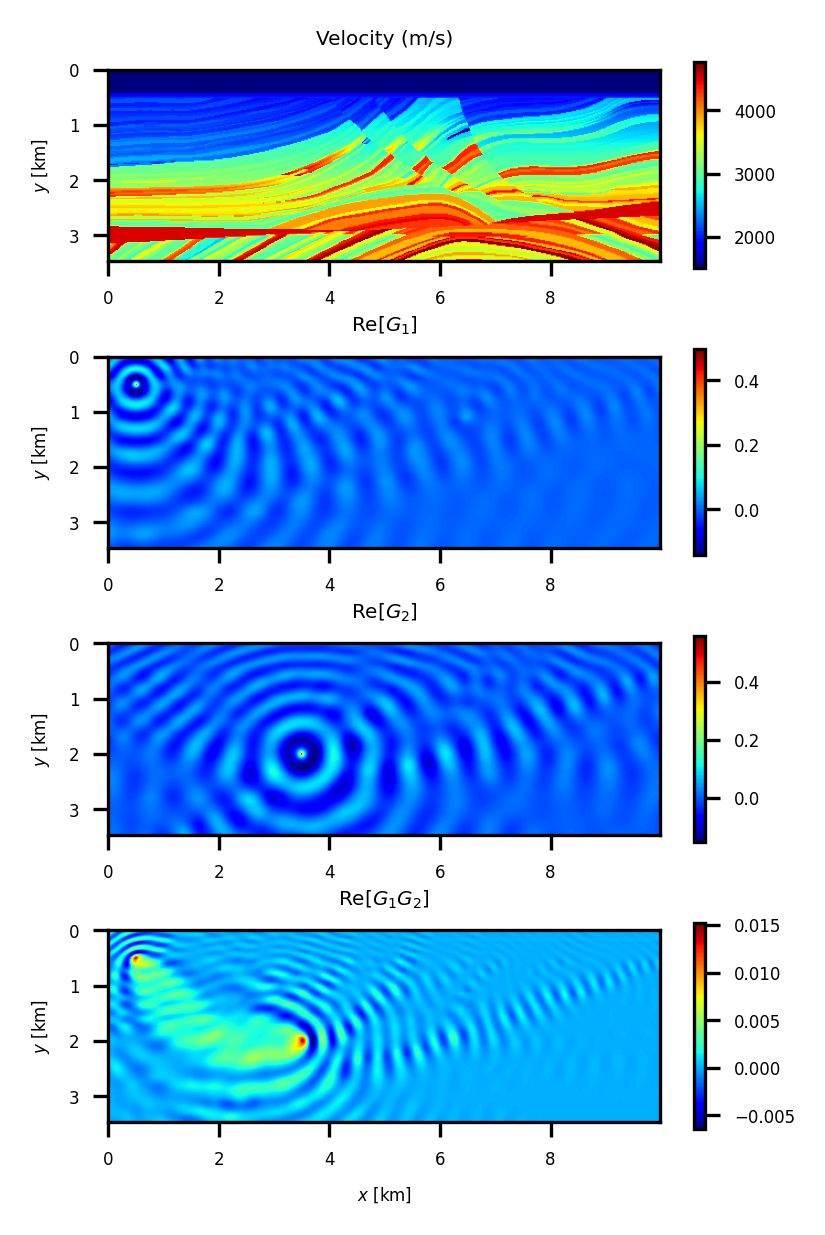

In [1]:
import numpy as np
from matplotlib.pyplot import *
import pyhelmholtz as ph

# load velocity model and define domain parameters
velocity = np.load("marmousi.npy")
domain = ph.Domain(h=20, v=velocity, positive_downward=True)

# define the sources
s1 = ph.PointSource(freq=5., xs=500, ys=500)
s2 = ph.PointSource(freq=5., xs=3500, ys=2000)

# create Helmholtz objects with 10-layer PML
ho1 = ph.Helmholtz(domain=domain, source=s1, abm=ph.PML(n=10))
ho2 = ph.Helmholtz(domain=domain, source=s2, abm=ph.PML(n=10))

# solve the linear systems using MUMPS
ho1.solve(solver="mumps"); G1 = ho1.u
ho2.solve(solver="mumps"); G2 = ho2.u

rcParams['font.size'] = 4
figure(figsize=(2.7,4),dpi=300)
subplot(411);ho1.viz(data="velocity", unit="km", title="Velocity (m/s)", xlabel=False)
subplot(412);ho1.viz(data="solution", unit="km", title="Re[$G_1$]", xlabel=False)
subplot(413);ho2.viz(data="solution", unit="km", title="Re[$G_2$]", xlabel=False)
subplot(414);ho1.viz(data=G1*G2, unit="km", title="Re[$G_1G_2$]")
gcf().tight_layout()